# EDA

Начинаем работать с датасетом! Собрали его с циана с помощью парсинга и вручную добавили оценку ремонта по фото (rating)

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import pandas as pd
import re
df = pd.read_csv('final_ultra_merged_ratings.csv', encoding='utf-8')
df.columns = df.columns.str.replace('\xa0', ' ').str.strip()

In [2]:
pd.set_option('display.max_columns', None)
df.sample(5)

,Ссылка,Заголовок,Цена,Оценка циана,ЖК,Агенство,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Год постройки,Метро,Адрес,Фото,Описание,Хорошая цена,Условие сделки,Ипотека,Тип жилья,Высота потолков,Санузел,Вид из окон,Ремонт,Перепланировка,Количество лифтов,Тип дома,Тип перекрытий,Подъезды,Придомовая территория,Парковка,Отопление,Аварийность,Несовершеннолетние собственники,Цены квартир рядом (за квадрат),С мебелью,Балкон/лоджия,Продаётся с мебелью,Газоснабжение,Материнский капитал при покупке,О подъезде,Только на Циан,Проверено в Росреестре,Строительная серия,Сделка от Циана,Размер доли,Аукцион,Год сдачи,Дом,Отделка,Онлайн-бронирование,Пандус,lat,lon,id,rating
4158,https://ekb.cian.ru/sale/flat/325733567/?conte...,"Продается студия, 28,8 м²",4 499 000 ₽,NaN,NaN,ГРАНАТ,"28,8 м²",16 м²,6 м²,14 из 16,2020.0,Ботаническая - 12 мин. - На машине|Чкаловская ...,Свердловская область|Екатеринбург|р-н Чкаловск...,https://images.cdn-cian.ru/images/2769119191-1...,Продаётся отличная квартира-студия в перспекти...,1.0,свободная продажа,возможна,Вторичка,NaN,1 совмещенный,NaN,Косметический,NaN,"1 пассажирский, 1 грузовой",NaN,Железобетонные,8.0,NaN,NaN,Центральное,Нет,NaN,NaN,1.0,NaN,Да,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.747383,60.571414,325733567,4
1485,https://ekb.cian.ru/sale/flat/329573005/?conte...,"Продается 2-комн. квартира, 70,5 м²",12 100 000 ₽,"12,2 млн ₽",NaN,Твой Дом,"70,5 м²","35,6 м²","15,1 м²",18 из 27,2012.0,Чкаловская - 11 мин. - Пешком|Ботаническая - 5...,Свердловская область|Екатеринбург|р-н Чкаловск...,https://images.cdn-cian.ru/images/kvartira-eka...,Продаётся светлая и просторная 2-комнатная ква...,1.0,свободная продажа,возможна,Вторичка,"2,75 м",1 раздельный,NaN,Евроремонт,Не было,"2 пассажирских, 2 грузовых",Монолитно-кирпичный,Железобетонные,7.0,"Шлагбаум, двор без машин",Подземная,Центральное,Нет,Нет,161 458 ₽/м²|160 337 ₽/м²|169 252 ₽/м²,1.0,1 лоджия,Да,NaN,Не использовался,Есть консьерж,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.804416,60.601400,329573005,3
2378,https://ekb.cian.ru/sale/flat/330803152/?conte...,"Продается 2-комн. квартира, 42,3 м²",4 499 000 ₽,"5,0 млн ₽",NaN,Этажи Екатеринбург,"42,3 м²",NaN,6 м²,2 из 3,1961.0,Проспект Космонавтов - 14 мин. - Пешком|Уралма...,Свердловская область|Екатеринбург|р-н Орджоник...,https://images.cdn-cian.ru/images/2895363612-1...,Продается двухкомнатная квартира 42.3 кв.м. на...,1.0,свободная продажа,NaN,Вторичка,"2,5 м",NaN,NaN,Косметический,NaN,NaN,Кирпичный,Железобетонные,3.0,NaN,Наземная,Центральное,Нет,NaN,96 470 ₽/м²|97 647 ₽/м²|104 761 ₽/м²,NaN,NaN,NaN,Центральное,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.912429,60.609153,330803152,2
2312,https://ekb.cian.ru/sale/flat/314781008/?conte...,"Продается 2-комн. квартира, 42,5 м²",5 550 000 ₽,"5,2 млн ₽",NaN,NaN,"42,5 м²",20 м²,10 м²,4 из 5,1962.0,Уралмаш - 24 мин. - Пешком|Проспект Космонавто...,Свердловская область|Екатеринбург|р-н Орджоник...,https://images.cdn-cian.ru/images/kvartira-eka...,Продаем уютную и очень функциональную квартиру...,1.0,альтернатива,возможна,Вторичка,"2,5 м",1 раздельный,Во двор,Евроремонт,NaN,NaN,Кирпичный,Железобетонные,4.0,NaN,Наземная,Центральное,Нет,NaN,120 805 ₽/м²|97 619 ₽/м²|130 588 ₽/м²,1.0,1 балкон,Да,Центральное,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.892384,60.584422,314781008,3
1587,https://ekb.cian.ru/sale/flat/329991091/?conte...,"Продается 2-комн. квартира, 62,1 м²",14 000 000 ₽,NaN,NaN,Дом мечты,"62,1 м²",NaN,12 м²,8 из 20,2012.0,Геологическая - 24 мин. - Пешком|Чкаловская - ...,Свердловская область|Екатеринбург|р-н Ленински...,https://images.cdn-cian.ru/images/2878752274-1...,"Продается просторная, очень теплая и уютная дв...",NaN,свободная продажа,возможна,Вторичка,"2,7 м",1 раздельный,На улицу и двор,Косметический,NaN,"2 пассажирских, 1 грузовой",Монолитный,Железобетонные,3.0,NaN,Подземная,Центральное,Нет,NaN,166 379 ₽/м²|196 261 ₽/м²|166 379 ₽/м²,NaN,1 лоджия,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [3]:
df['id'].duplicated().sum()

np.int64(0)

In [4]:
df.shape

(4304, 55)

После парсинга, склиевания датасетов и удаления дубликатов в итоговом датасете осталось 4304 квартиры и 55 признаков

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4304 entries, 0 to 4303
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ссылка                           4304 non-null   object 
 1   Заголовок                        4304 non-null   object 
 2   Цена                             4304 non-null   object 
 3   Оценка циана                     2914 non-null   object 
 4   ЖК                               1031 non-null   object 
 5   Агенство                         2919 non-null   object 
 6   Общая площадь                    4304 non-null   object 
 7   Жилая площадь                    3541 non-null   object 
 8   Площадь кухни                    4051 non-null   object 
 9   Этаж                             4304 non-null   object 
 10  Год постройки                    4188 non-null   float64
 11  Метро                            3912 non-null   object 
 12  Адрес               

Имеем множество признаков, среди самых важных: цена квартиры, площадь, описание, метро. Большинство признаков имеют большое количество пропусков в связи с тем, что не являются обязательными для заполнения полями при публикации обьявления на Циан, поработаем с этим позднее. Начнем работать с каждым признаком.

Для начала посмотрим на признаки с большим количеством пропусков (больше половины)

In [6]:
cols = df.columns[df.isna().mean() > 0.5].tolist()
for c in cols:
    print(c)
    print(f'Количество пропусков: {df[c].isna().sum()}')
    print(f'Уникальные значения: {df[c].unique()}')
    print()

ЖК
Количество пропусков: 3273
Уникальные значения: ['ЖК «Рудный»' nan 'ЖК «Садовый»' 'ЖК «Хрустальные Ключи»'
 'ЖК «Ньютон Парк»' 'ЖК «Новый ВИЗ»' 'ЖК «Русь»'
 'ЖК «Жилой район Солнечный»' 'ЖК «Современник»'
 'ЖК «Clever park (Клевер парк)»' 'ЖК «Спутник-1»'
 'ЖК «Екатерининский парк»' 'ЖК «Светлый»' 'ЖК «Петровский»'
 'ЖК «Кварталы Форум Групп (р-н Солнечный)»' 'ЖК «Фристайл»'
 'ЖК «Квартал Федерация»' 'ЖК «Суходольский квартал»' 'ЖК «Рябина-парк»'
 'ЖК «Космонавтов 11»' 'ЖК «Философия Идеалистов на Черкасской»'
 'ЖК «Тёплые кварталы»' 'ЖК «Академик»' 'ЖК «River Park (Ривер Парк)»'
 'ЖК «Ленина 8»' 'ЖК «Совушки»' 'ЖК «Цветной бульвар»' 'ЖК «А Плюс»'
 'ЖК «Астон. Событие»' 'ЖК «Макаровский»' 'ЖК «Нова Парк»'
 'ЖК «Брусника в Академическом»' 'ЖК «Притяжение»' 'ЖК «МонтеКристо»'
 'ЖК «Каменный ручей»' 'ЖК «Весна»' 'ЖК «Мичуринский»' 'ЖК «Раута»'
 'ЖК «Тишина»' 'ЖК «Исеть парк»' 'ЖК «Садовый-2»' 'ЖК «Астон. Реформа»'
 'ЖК «Новокольцовский»' 'ЖК «Квартал «Сюжеты»»' 'ЖК «Горки»'
 'ЖК «Астон

Имеем пять признаков, которые мы можем перевести в бинарные, интерпретируя пропуск как 0: наличие объявления только на циан, факт проверки в росреестре, факт проведения аукциона, наличие хорошей цены, продажа с мебелью или без (признаки "с мебелью" и "продается с мебелью" дублируют друг друга). Также переведем признак размер доли в числовой, а пропуски заполним 0 (нулевая доля, ее отсутствие).

Есть также бинарные признаки (например, наличие перепланировки), где среди уникальных значений два бинарных и большое количество пропусков, что не пользовляет нам как-либо заполнить пропуски, придется их удалить. Признак "Сделка от Циана", хоть и является бинарным, однако несет очень мало информации (всего 9 сделок от циана).

Наличие ЖК может быть важным признаком, однако их слишком много, поэтому также превратим ЖК в бинарный признак.

Удалим остальные признаки

In [7]:
def share(v):
    if pd.isna(v):
        return 0
    v = v.strip()
    if '/' in v:
        a, b = v.split('/')
        return float(a) / float(b)
    else:
        return float(v)

df['Размер доли'] = df['Размер доли'].apply(share)


df['Аукцион'] = df['Аукцион'].fillna(0).astype(int)
df['Только на Циан'] = df['Только на Циан'].fillna(0).astype(int)
df['Проверено в Росреестре'] = df['Проверено в Росреестре'].fillna(0).astype(int)
df['Хорошая цена'] = df['Хорошая цена'].fillna(0).astype(int)
df['С мебелью'] = df['С мебелью'].fillna(0).astype(int)

df['Квартира в ЖК'] = df['ЖК'].notna().astype(int)

cols_to_drop = [
    'ЖК', 'Вид из окон', 'Перепланировка', 'Придомовая территория',
    'Несовершеннолетние собственники', 'Продаётся с мебелью',
    'Газоснабжение', 'Материнский капитал при покупке', 'О подъезде',
    'Строительная серия', 'Сделка от Циана',
    'Год сдачи', 'Дом', 'Отделка', 'Онлайн-бронирование', 'Пандус']

df = df.drop(columns=cols_to_drop)

Удалим ссылку (как неинформативный для модели текстовый признак) и адрес (так как вместо него имеем широту и долготу), а также ссылки на фото. С признаком описания будем работать позже, оставляем его

In [8]:
df = df.drop(columns=['Адрес','Ссылка','Фото'])

Обработаем признаки цены, площади и высоты потолков. Для начала приведем все это счастье в тип int или float

In [9]:
df['Цена'] = df['Цена'].str.replace('\xa0','').str.replace('₽', '').str.replace('RUB', '').str.replace(',', '').str.replace('.00', '').astype(int)
df['Оценка циана'] = df['Оценка циана'].str.replace('\xa0','').str.replace('млн ₽', '').str.replace(' ', '').str.replace(',', '.').astype(float) * 10**6

df['Общая площадь'] = df['Общая площадь'].str.replace('\xa0м²', '').str.replace(',', '.').astype(float)
df['Жилая площадь'] = df['Жилая площадь'].str.replace('\xa0м²', '').str.replace(',', '.').astype(float)
df['Площадь кухни'] = df['Площадь кухни'].str.replace('\xa0м²', '').str.replace(',', '.').astype(float)

df['Высота потолков'] = df['Высота потолков'].str.replace('\xa0м','').str.replace(',','.').astype(float)

Помимо этого, убедимся, что признак "Хорошая цена" не бесполезный.

In [10]:
df[(df['Оценка циана'] < df['Цена']) & (df['Хорошая цена'] == 1)].shape[0]

732

Видим, что есть аж 732 квартиры, где оценка циана ниже фактической цены, однако плашка "хорошая цена" все равно висит в объявлении, то есть этот признак полезный

Обработаем этаж: он идет в формате (k из n), поэтому выделим сам этаж и его этажность

In [11]:
def floor_s(x):
    if pd.isna(x):
        return [None, None]
    return x.split(' из ')

df[['Этаж', 'Этажность']] = df['Этаж'].apply(floor_s).tolist()
df['Этаж'] = df['Этаж'].astype(int)
df['Этажность'] = df['Этажность'].astype(int)

Обработаем метро, пропуски в данном случае означают отсутствие метро, возьмем из всех вариантов самый ближайшие, при том, если есть варианты пешей доступности, возьмем ближайший из них, а если нету, то ближайший из вариантов "на машине"

In [12]:
def metro(x):
    if pd.isna(x):
        return ['Нет', 0, 'Нет']

    met = []
    for i in x.split('|'):
        parts = i.split(' - ')

        station = parts[0]
        time = int(parts[1].replace(' мин.', ''))
        way = parts[2]

        met.append([station, time, way])

    walk = [r for r in met if r[2] == 'Пешком']
    if walk:
        b = min(walk, key=lambda x: x[1])
    else:
        b = min(met, key=lambda x: x[1])
    return b

df[['Станция метро', 'Время до метро', 'Способ до метро']] = df['Метро'].apply(metro).tolist()
df = df.drop(columns=['Метро'])

df['Время до метро'] = df['Время до метро'].astype(int)

Обработаем санузлы, количество лифтов и лоджий. Для них оставим количество тех и других, суммируя совмещенные и раздельные санузлы и пассажирские и грузовые лифты, а также балконы и лоджии

In [13]:
def toilets_lifts_balk(s):
    if pd.isna(s):
        return np.nan
    return sum([int(w) for w in str(s).split() if w.isdigit()])
df['Количество санузлов'] = df['Санузел'].apply(toilets_lifts_balk).astype('Int64')
df = df.drop(columns=['Санузел'])
df['Количество лифтов'] = df['Количество лифтов'].apply(toilets_lifts_balk).astype('Int64')
df['Количество балконов/лоджий'] = df['Балкон/лоджия'].apply(toilets_lifts_balk).astype('Int64')
df = df.drop(columns=['Балкон/лоджия'])

Ипотека - бинарный признак, поэтому заменим пропуски на 0

In [14]:
df['Ипотека'] = df['Ипотека'].str.replace('возможна', '1').fillna('0').astype(int)

Пропуски в признаке "тип дома" заполним строкой "неизвестно".

In [15]:
df['Тип дома'] = df['Тип дома'].fillna('Неизвестно')

Для признака агенства пропусков чуть меньше половины и большое количество уникальных значений, поэтому так же как и с ЖК переведем агенство в бинарный признак "Продается агенством"

In [16]:
df['Продается агенством'] = df['Агенство'].notna().astype(int)
df = df.drop(columns=['Агенство'])

Обработаем заголовок. Сначала выделим текст после слова "продается"/"продаются", избавимся от квадратуры в заголовке.

In [17]:
def zag(x):
    if 'Продается' in x:
        if '0,29' in x:
            return '0,29 квартиры'
        return x.split('Продается')[1].split(',')[0].strip()
    return x.split('Продаются')[1].split(',')[0].strip()
df['Заголовок'] = df['Заголовок'].apply(zag)
df['Заголовок'].unique()

array(['1-комн. квартира', '1-комн. апартаменты', '1/2 квартиры',
       '2-комн. квартира', 'апартаменты-студия', 'студия', '1/3 квартиры',
       '2-комн. апартаменты', '2/3 квартиры', '3-комн. квартира',
       '3-комн. апартаменты', 'доля', '0,29 квартиры', '46/100 квартиры',
       '4-комн. квартира', '4-комн. апартаменты', '5-комн. квартира',
       'многокомнатная квартира', 'квартира свободной планировки',
       'апартаменты свободной планировки'], dtype=object)

Видим, что можно выделить тип жилья (квартира, апартаменты, студия) и количество комнат. Факт доли выделять не будем, такой признак уже есть

In [18]:
def rooms(t):
    if 'студия' in t:
        return 1
    if '/' in t or 'доля' in t:
        return None
    if '-комн' in t:
        return int(t.split('-комн')[0])
    return None

def typ(t):
    if 'квартира' in t or 'квартиры' in t:
        return 'квартира'
    if 'апартаменты' in t:
        return 'апартаменты'
    if 'студия' in t:
        return 'студия'
    return 'Неизвестно'

df['Количество комнат'] = df['Заголовок'].apply(rooms)
df['Тип объекта'] = df['Заголовок'].apply(typ)

df = df.drop(columns=['Заголовок'])

Наконец, посчитаем среднюю цену квартир рядом (за квадрат)

In [19]:
def avg(pr):
    if pd.isna(pr):
        return None
    prices = []
    for p in pr.split('|'):
        # Удаляем лишние символы: пробелы, ₽/м², заменяем запятую на точку
        p = p.strip().replace('\xa0', '').replace('₽/м²', '').replace(' ', '').replace(',', '.')
        prices.append(float(p))
    return sum(prices) / len(prices)

df['Цены квартир рядом (за квадрат)'] = df['Цены квартир рядом (за квадрат)'].apply(avg)

In [20]:
df.sample(5)

,Цена,Оценка циана,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Год постройки,Описание,Хорошая цена,Условие сделки,Ипотека,Тип жилья,Высота потолков,Ремонт,Количество лифтов,Тип дома,Тип перекрытий,Подъезды,Парковка,Отопление,Аварийность,Цены квартир рядом (за квадрат),С мебелью,Только на Циан,Проверено в Росреестре,Размер доли,Аукцион,lat,lon,id,rating,Квартира в ЖК,Этажность,Станция метро,Время до метро,Способ до метро,Количество санузлов,Количество балконов/лоджий,Продается агенством,Количество комнат,Тип объекта
121,6250000,NaN,34.8,11.0,13.0,14,2022.0,"В продаже однокомнатная квартира 34,8 кв.м. на...",1,свободная продажа,1,Вторичка,NaN,Косметический,4,Неизвестно,Железобетонные,1.0,Наземная,Центральное,Нет,NaN,0,0,0,0.0,0,56.859862,60.649199,329896027,2,1,34,Машиностроителей,6,На машине,1,<NA>,1,1.0,квартира
3735,49500000,38500000.0,125.0,70.0,46.0,22,2018.0,Продается четырехкомнатная квартира в самом це...,0,свободная продажа,1,Вторичка,2.8,Дизайнерский,3,Монолитный,Железобетонные,2.0,Подземная,Центральное,Нет,258564.666667,1,0,0,0.0,0,56.828640,60.594645,329345169,5,0,32,Геологическая,10,Пешком,2,1,1,4.0,квартира
3750,4980000,5600000.0,65.5,45.0,6.0,5,1990.0,Продается четырехкомнатная квартира в центре г...,0,альтернатива,1,Вторичка,2.5,Косметический,<NA>,Блочный,Железобетонные,4.0,NaN,Центральное,Нет,85188.333333,0,0,0,0.0,0,56.971212,60.580775,330419236,2,0,5,Нет,0,Нет,1,1,1,4.0,квартира
1655,5490000,4900000.0,42.6,28.0,6.0,6,1976.0,Арт. 134639638 Продается квартира в развитом р...,0,свободная продажа,1,Вторичка,NaN,Косметический,1,Панельный,Железобетонные,6.0,NaN,Центральное,Нет,118384.000000,0,0,0,0.0,0,56.906546,60.594312,329061759,3,0,9,Проспект Космонавтов,18,Пешком,1,1,1,2.0,квартира
3969,3730000,NaN,20.2,13.2,2.0,11,2026.0,Арт. 136716232 Продам студию в новом жилом ком...,0,свободная продажа,1,Вторичка,2.7,Евроремонт,3,Монолитный,NaN,NaN,Наземная,NaN,NaN,181169.000000,0,0,0,0.0,0,56.797501,60.526103,330796553,4,1,25,Геологическая,9,На машине,1,1,1,1.0,студия


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Категориальные признаки

Будем анализировать следующие категориальные признаки:

In [22]:
categorical_features = [
    'Ремонт',
    'Тип дома',
    'Парковка',
    'Отопление',
    'Способ до метро',
    'Продается агенством',
    'Квартира в ЖК',
    'Условие сделки',
    'Ипотека',
    'Тип жилья',
    'Аварийность']

In [23]:
df[categorical_features].nunique()

,0
Ремонт,4
Тип дома,10
Парковка,4
Отопление,7
Способ до метро,3
Продается агенством,2
Квартира в ЖК,2
Условие сделки,4
Ипотека,2
Тип жилья,3


Как мы видим, после предобработки наши категориальные признаки стали принимать не так уж много значений, а значит, можем изобразить их распределения на графике. Категориальных признаков 11 штук, поэтому начнем визуализацию с первых 6:

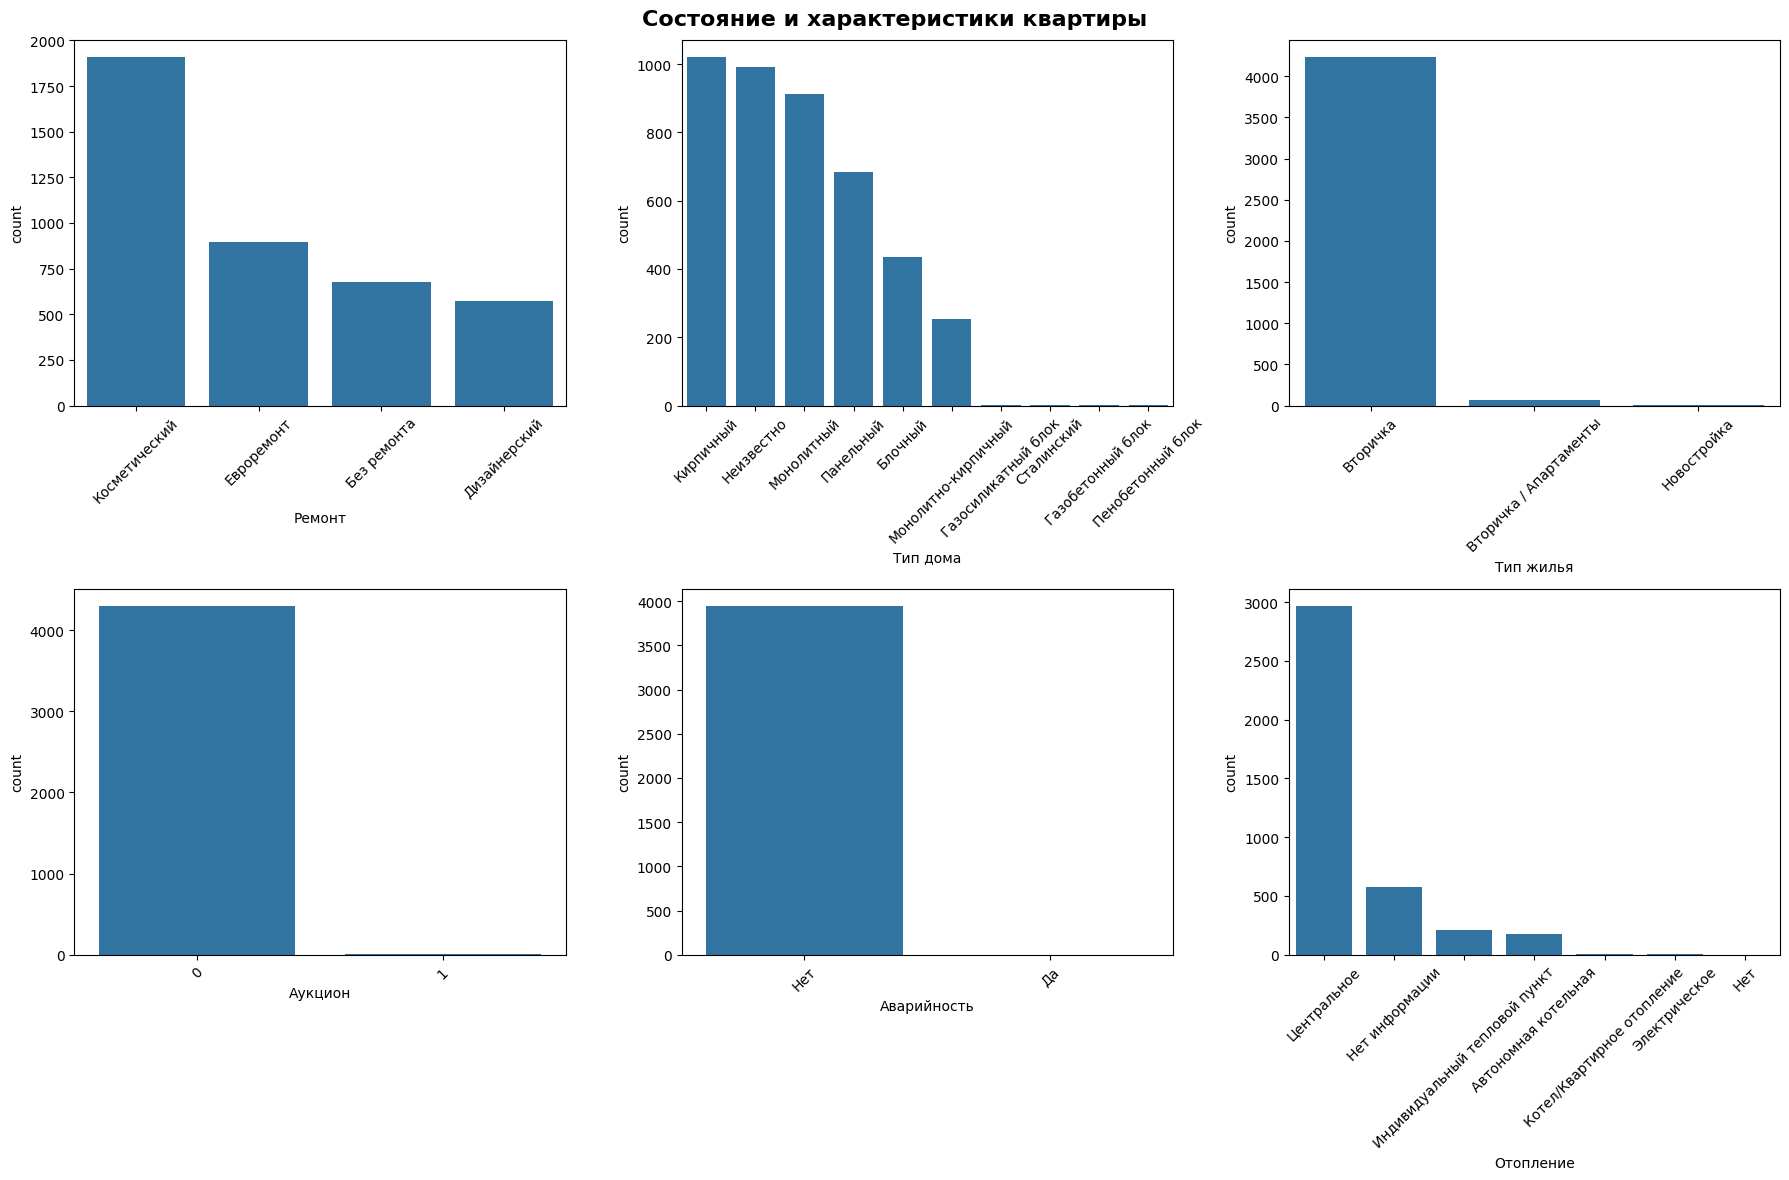

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18,12))
fig.suptitle('Состояние и характеристики квартиры', fontsize=16, fontweight='bold')
sns.countplot(data=df, x='Ремонт', ax=axes[0,0], order=df['Ремонт'].value_counts().index)
sns.countplot(data=df, x='Тип дома', ax=axes[0,1], order=df['Тип дома'].value_counts().index)
sns.countplot(data=df, x='Тип жилья', ax=axes[0,2], order=df['Тип жилья'].value_counts().index)
sns.countplot(data=df, x='Аукцион', ax=axes[1,0], order=df['Аукцион'].value_counts().index)
sns.countplot(data=df, x='Аварийность', ax=axes[1,1], order=df['Аварийность'].value_counts().index)
sns.countplot(data=df, x='Отопление', ax=axes[1,2], order=df['Отопление'].value_counts().index)

for i in range(2):
  for j in range(3):
    axes[i,j].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Вот что мы видим:
- Первое, что сразу бросается в глаза - это признак Аварийность, который в почти 100% случаев принимает значение 'Нет'. Это логично, что ни один заинтересованный в продаже квартиры человек не станет указывать ее недостаток, если его можно не указывать


In [25]:
df['Аварийность'].value_counts()

,count
Аварийность,
Нет,3940
Да,1


Всего нашелся один человек, который решил в этом признаться. Исходя из этого, признак не является содержательным, поэтому его можно и нужно удалить

In [26]:
df = df.drop('Аварийность', axis=1)

- То же самое касается признака 'Аукцион': слишком мало квартир, продающихся на аукционе, а именно:

In [27]:
df['Аукцион'].value_counts()

,count
Аукцион,
0,4294
1,10


Все лишь 10. Это будет лишним шумом для нашей будущей модели, поэтому лучше либо удалить этот признак, либо удалить эти 10 квартир. Но так как цены на квартиры, продающиеся на аукционе стоят заниженные (начальные), они будут искажать реальную картину и лучше удалить такие квартиры:

In [28]:
df = df.drop(df[df['Аукцион'] == 1].index)

Идем далее
- Изначально мы собирали только квартиры с рынка вторичного жилья, однако каким-то образом к нам попали несколько квартир из новостроек (ошибка выдачи Циана), эти квартиры необходимо удалить

In [29]:
df = df.drop(df[df['Тип жилья'] == 'Новостройка'].index)

Остальные признаки имеют логичное, ожидаемое распределение:
- Преобладающий тип ремонта Косметический, меньше всего квартир с дизайнерским ремонтом
- Очень часто люди не указывают тип дома; больше всего преобладают кирпичные, монолитные и панельные дома
- По типу отопления доминирует центральное, реже всего встречаются квартиры без отопления совсем

Эти признаки мы удалять не будем, однако позже посмотрим, что можно сделать с пропусками

Посмотрим на оставшиеся категориальные признаки:

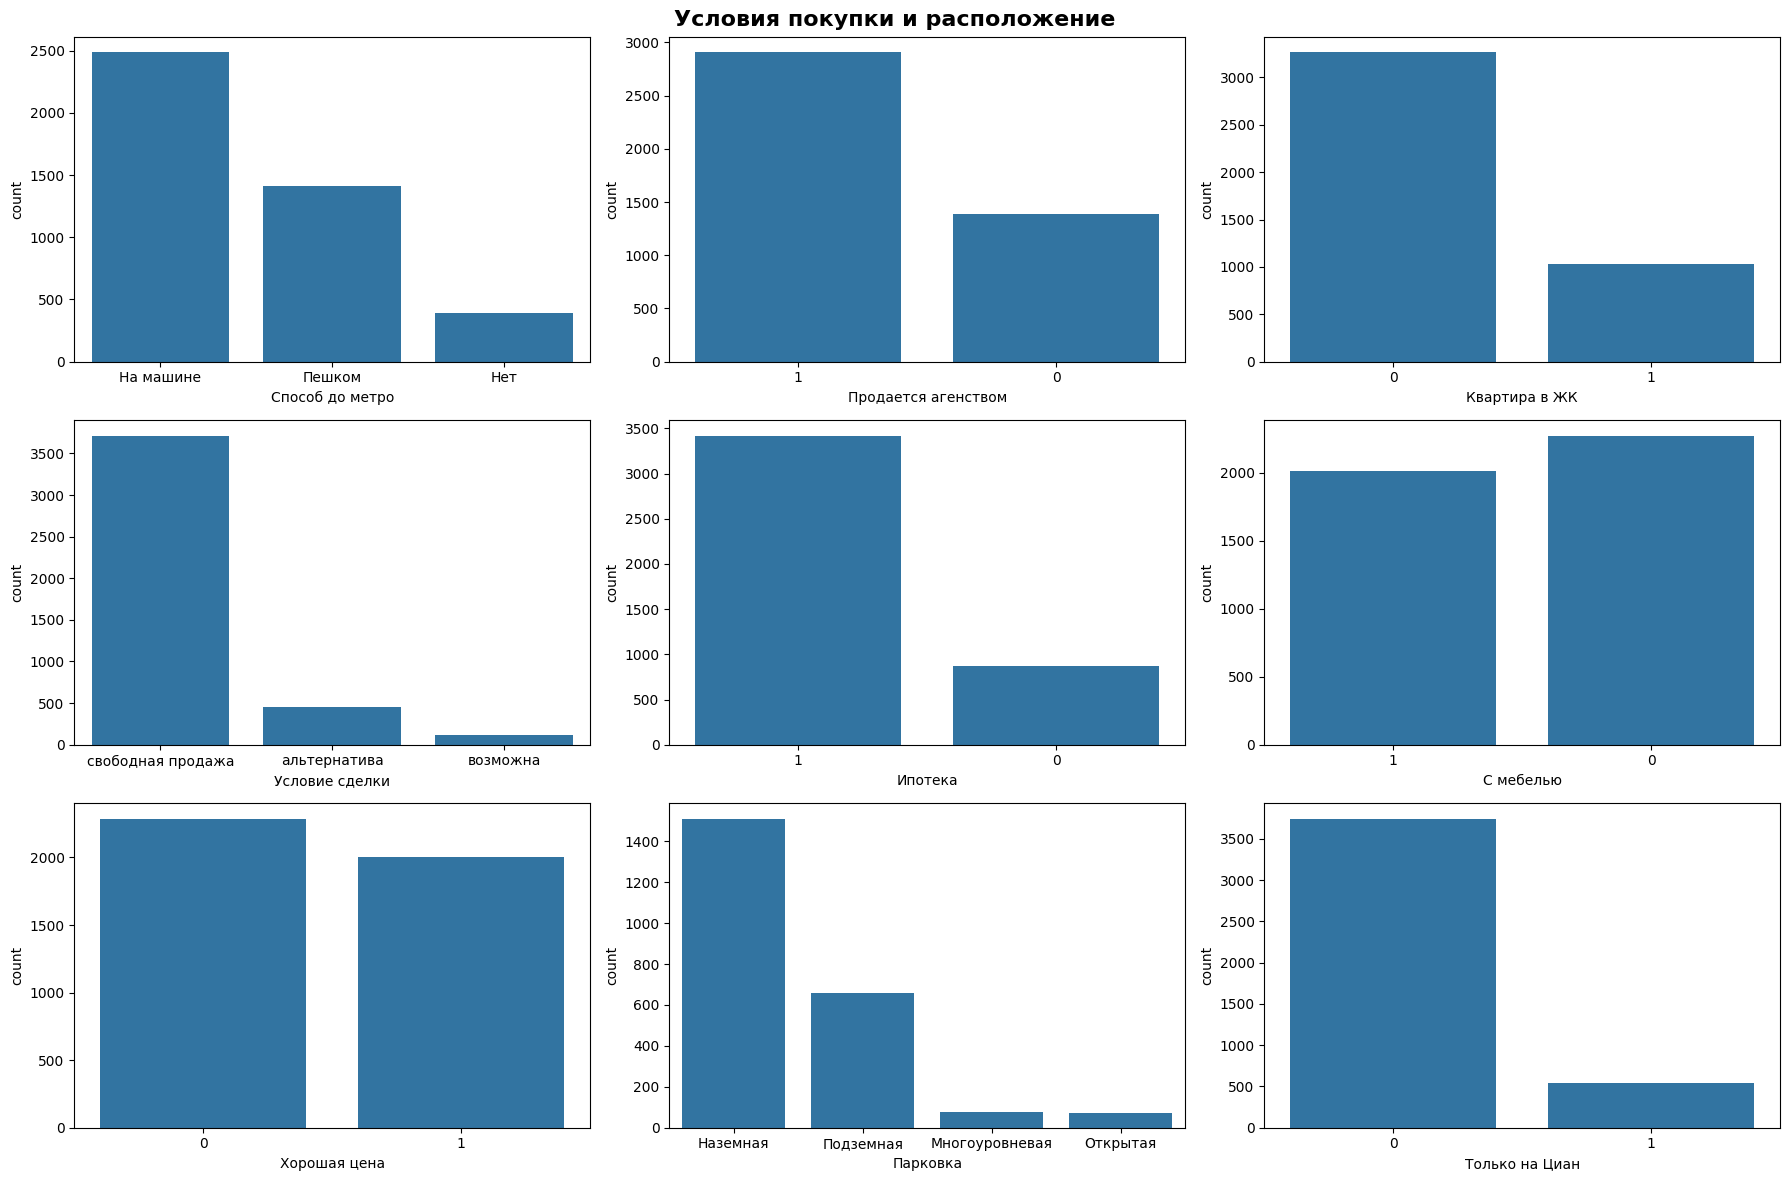

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(18,12))
fig.suptitle('Условия покупки и расположение', fontsize=16, fontweight='bold')
sns.countplot(data=df, x='Способ до метро', ax=axes[0,0], order=df['Способ до метро'].value_counts().index)
sns.countplot(data=df, x='Продается агенством', ax=axes[0,1], order=df['Продается агенством'].value_counts().index)
sns.countplot(data=df, x='Квартира в ЖК', ax=axes[0,2], order=df['Квартира в ЖК'].value_counts().index)
sns.countplot(data=df, x='Условие сделки', ax=axes[1,0], order=df['Условие сделки'].value_counts().index)
sns.countplot(data=df, x='Ипотека', ax=axes[1,1], order=df['Ипотека'].value_counts().index)
sns.countplot(data=df, x='С мебелью', ax=axes[1,2], order=df['Ипотека'].value_counts().index)
sns.countplot(data=df, x='Хорошая цена', ax=axes[2,0], order=df['Хорошая цена'].value_counts().index)
sns.countplot(data=df, x='Парковка', ax=axes[2,1], order=df['Парковка'].value_counts().index)
sns.countplot(data=df, x='Только на Циан', ax=axes[2,2], order=df['Только на Циан'].value_counts().index)

plt.tight_layout()
plt.show()

Итак, вот что мы видим:
- Квартир со способом добраться до метро пешком почти в 2 раза меньше, чем на машине
- Квартир, продающихся агенствами в два раза больше, чем квартир, продающихся без их участия
- Квартир в ЖК очень мало, почти в 3 раза меньше, чем без ЖК
- В условиях сделки доминирует 'свободная продажа', 'альтернатива' и 'возможна' гораздо более редки
- Большинство квартир доступно в ипотеку - они преобладают над квартирами без опотеки более чем в 3 раза
- Без мебели квартир продается чуть больше, однако их примерно одинаково много
- Распределение квартир с пометкой хорошей цены (оценки Циана) и без нее - примерно 50 на 50, но квартир без такой оценки чуть-чуть больше
- Квартир с наземной парковкой примерно в два раза больше, чем квартир с подземной - вероятно вторые будут стоить дороже. Очень мало с многоуровневой и открытой типами парковок
- Квартиры с пометкой 'Только на Циан' встречаются аж в 7 раз реже, чем квартиры без такой пометки - либо такие квартиры не проходили проверку на наличие объявлений на других площадках, либо люди очень редко публикуют объявление о продаже только на одной площадке

### Числовые признаки

Будем анализировать следующие чсиловые признаки:

In [31]:
numeric_features = [
    'Цена',
    'Оценка циана',
    'Общая площадь',
    'Жилая площадь',
    'Площадь кухни',
    'Этаж',
    'Год постройки',
    'Высота потолков',
    'Количество лифтов',
    'Подъезды',
    'Цены квартир рядом (за квадрат)',
    'rating',
    'Количество санузлов',
    'Количество балконов/лоджий',
    'Количество комнат']

In [32]:
df_num = df[numeric_features]

Перво-наперво нам будет интересно посмотреть на матрицу корреляции числовых признаков:

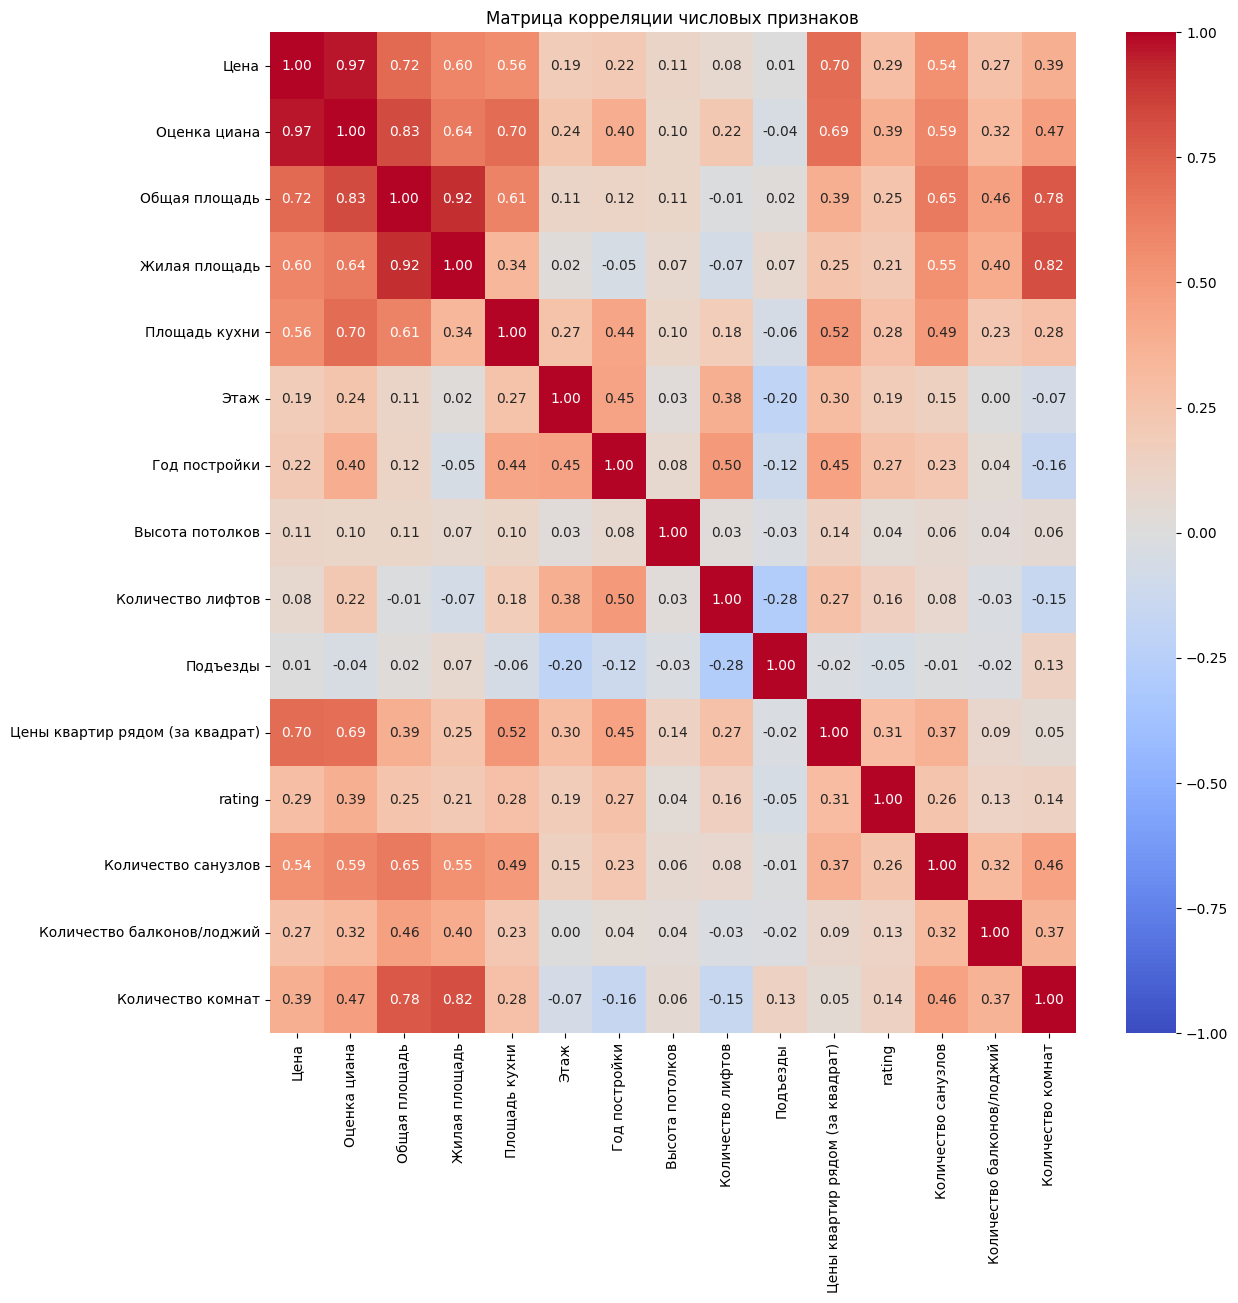

In [33]:
plt.figure(figsize=(13,13))
plt.title('Матрица корреляции числовых признаков', )
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.show()

В целом видно, что многие признаки имеют высокую корреляцию, это касается практически всех признаков связанных с ценой (например, Цена и Оценка циана очевидно будут примерно в одном и том же диапазоне), а также прочих очевидных корреляций по типу Цена - Общая площадь и так далее. Однако хочется выделить и несколько менее очевидных:
- Цены квартир рядом (за квадрат) имеют умеренную положительную корреляцию с Площадью кухни. Вероятно, это связано с тем, что просторные кухни чаще встречаются в ЖК высокого класса, которые расположены в локациях с более дорогим квадратным метром. Т.е. размер кухни является маркером общего качества и статуса жилья, что тянет за собой и стоимость соседних квартир. Аналогично с кол-вом санузлов
- Подъезды слабо отрицательно коррелируют с Кол-вом лифтов, скорее всего потому что в домах с большим кол-вом подъездов лифтов на подъезд обычно меньше
- Год постройки также умеренно положительно коррелирует с Кол-вом лифтов, видимо это связано с ростом этажности с течением времени и с требованиями к комфорту
- Цены квартир рядом (за квадрат) логично коррелируют с Годом постройки, чем новее инфраструктура, тем дороже в этом районе квартиры

В рамках нашего проекта нам будет очень полезно на  посмотреть на распределение средней цены в зависимости от типа ремонта:

In [34]:
mean_prices = df.groupby('Ремонт')['Цена'].mean().sort_values(ascending=False) / 1000000

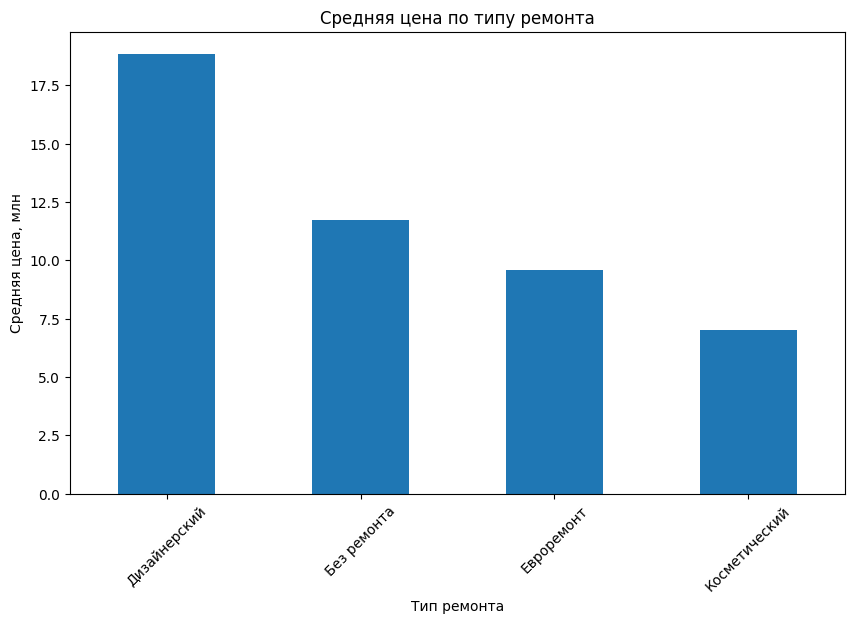

In [35]:
plt.figure(figsize=(10,6))
mean_prices.plot(kind='bar')
plt.title('Средняя цена по типу ремонта')
plt.xlabel('Тип ремонта')
plt.ylabel('Средняя цена, млн')
plt.xticks(rotation=45)
plt.show()

Ситуация следующая:
- Квартиры с дизайнерским ремнтом стоят больше всего и по судя по средней цене в >17.5 млн они чаще всего имеют больше одной комнаты
- Далее, как ни странно, идут квартиры без ремонта. Это объясняется тем, что такие квартиры продают перекупы, которые купили квартиру в новостройке подешевле и продают на вторичном рынке подороже
- После идет евроремонт (капитальный ремонт по современным стандартам) и косметический (более быстрый, без замены планировки)

Теперь посмотрим на распределение среднего rating в зависимости от типа ремонта:

In [40]:
mean_ratings = df.groupby('Ремонт')['rating'].mean().sort_values(ascending=False)

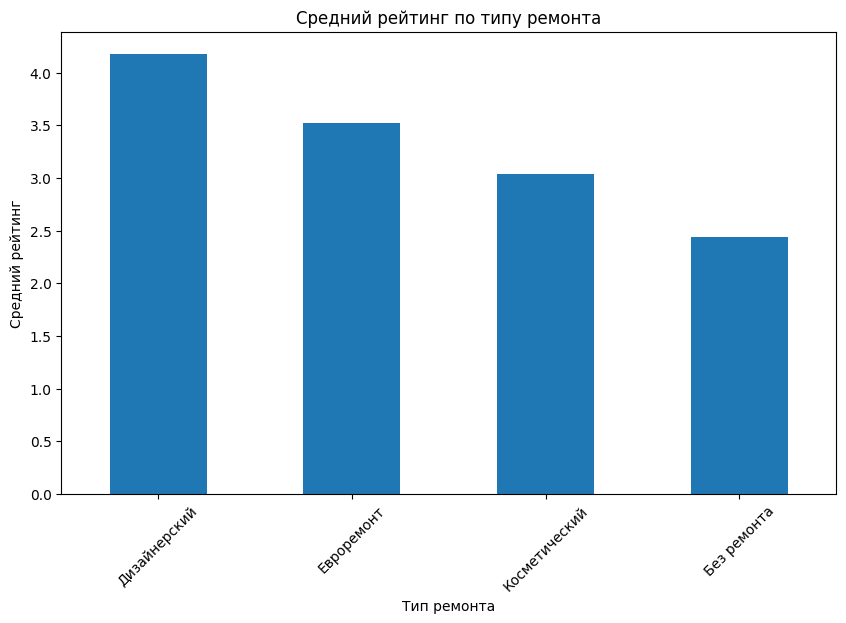

In [43]:
plt.figure(figsize=(10,6))
mean_ratings.plot(kind='bar')
plt.title('Средний рейтинг по типу ремонта')
plt.xlabel('Тип ремонта')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.show()

Здесь все закономерно: оценки выставлялись по общему состоянию квартиры, поэтому на графике видно, что у дизайнерского типа ремонта наивысшая средняя оценка, а у квартир без ремонта - наименьшая

### Выбросы

Также посмотрим на выбросы:

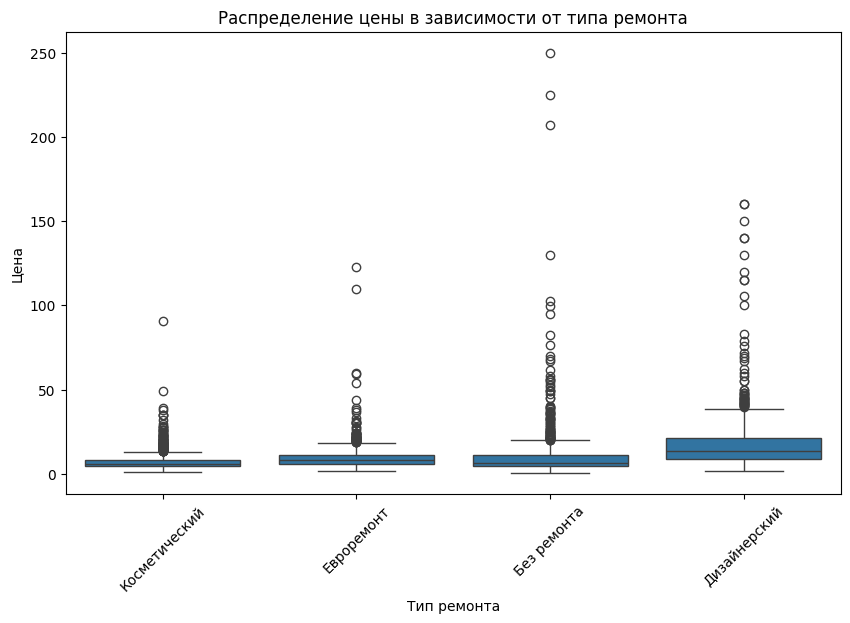

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x=df['Ремонт'], y=df['Цена'] / 1000000)
plt.title('Распределение цены в зависимости от типа ремонта')
plt.xticks(rotation=45)
plt.ylabel('Цена')
plt.xlabel('Тип ремонта')
plt.show()

- Квартиры с самыми высокими ценами не имеют ремонта - опять же дело в тех новостройках (по всей видимости очень престижных), которые перепродают перекупы. Мы загуглили, и нашли, что одни из таких квартир это огромные двухэтажные апартаменты в башне «Исеть» без ремонта, и стоят они до 250 млн
- Достаточно много выбросов (при том больших) и в квартирах с дизайнерским ремонтом, однако вышеописанных экземпляров там нет
- В квартирах с косметическим ремонтом и евроремонтом выбросов меньше, но их тоже немало

Более наглядно можно будет посмотреть на распределение с помощью violinplot:

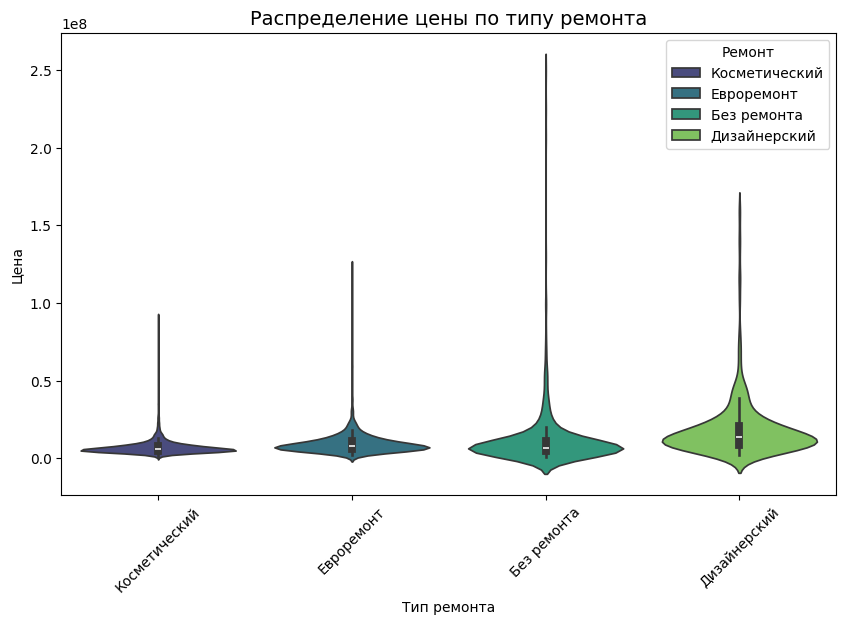

In [55]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Ремонт', y='Цена', palette='viridis', hue='Ремонт')
plt.title('Распределение цены по типу ремонта', fontsize=14)
plt.xlabel('Тип ремонта')
plt.ylabel('Цена')
plt.xticks(rotation=45)
plt.show()

- Самое острое распределение у квартир с косметическим ремонтом, цены на них как правило в самом узком диапазоне
- Самое пологое распределение цен у квартир с дизайнерским ремонтом, это связано с бОльшим разбросом цен на такие квартиры


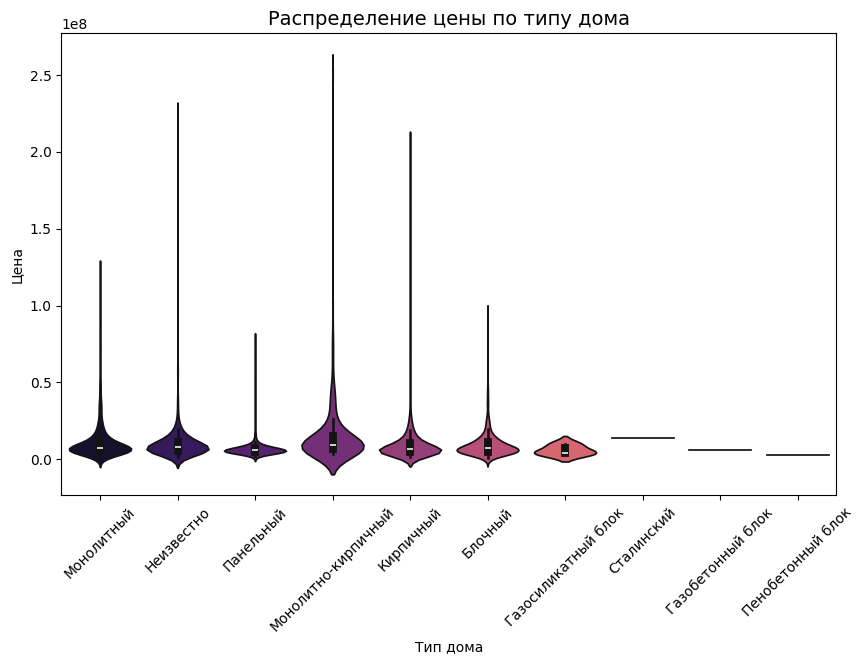

In [56]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Тип дома', y='Цена', palette='magma', hue='Тип дома')
plt.title('Распределение цены по типу дома', fontsize=14)
plt.xlabel('Тип дома')
plt.ylabel('Цена')
plt.xticks(rotation=45)
plt.show()

- Сразу бросается в глаза, что по всей видимости квартир, у которых тип дом сталинский/газобетонный блок/пенобетонный блок, встречаются буквально единицы
- Самый высокий медианный ценник у монолита, при этом распределение довольно широкое. Это говорит о том, что монолит является предсказуемым премиум-сегментом
- У кирпичных домов медиана чуть ниже, но распределение уже. Это может быть связано с тем, что состояния кирпичных домов более предсказуемые
- Панельные дома дают самый короткий хвост и самое узкое распределение, однако все равно есть выбросы вверх, видимо там сделали ооочень хороший ремонт

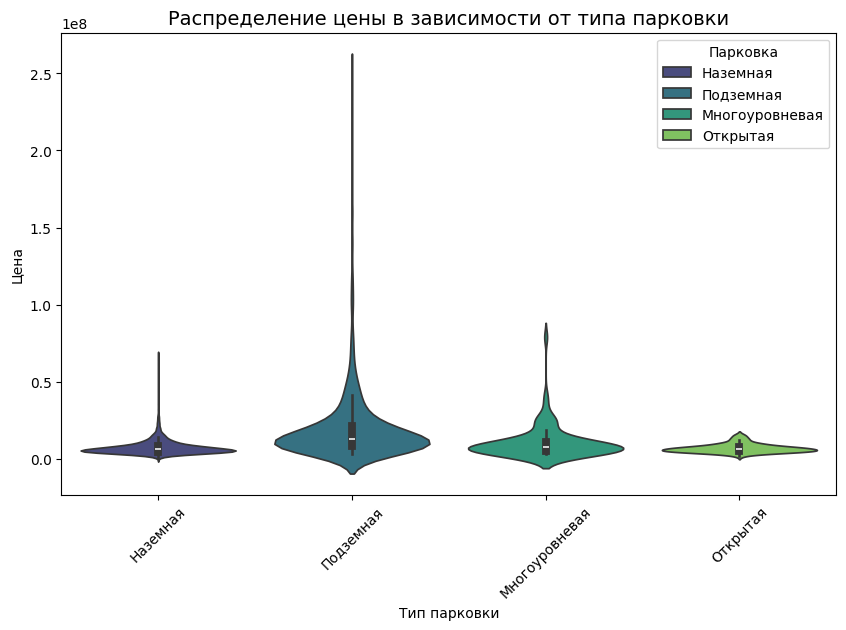

In [61]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Парковка', y='Цена', palette='viridis', hue='Парковка')
plt.title('Распределение цены в зависимости от типа парковки', fontsize=14)
plt.xlabel('Тип парковки')
plt.ylabel('Цена')
plt.xticks(rotation=45)
plt.show()

- Поземная парковка имеет самый длинный хвост и самое широкое распределение и самую высокую цену, это явный признак ЖК бизнес-класса, где квартиры соответствующие
- У многоуровневого типа парковки можно с натяжкой сказать что бимодальное распределение, в какой-то момент квартиры с очень высокими ценами вдруг начинают строить многоуровневые парковки, в то время как правило такие делают дома средней ценовой категории
- У открытой парковки закономерно нет выбросов, такие дома не могут стоить дорого, это явный указатель относительно недорогой квартиры

Посчитаем выбросы по методу IQR:


In [37]:
df.groupby('Ремонт')['Цена'].apply(lambda x:
 (x.quantile(0.25)-1.5*(x.quantile(0.75)-x.quantile(0.25)),
  x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25))))

,Цена
Ремонт,
Без ремонта,"(-4281250.0, 19968750.0)"
Дизайнерский,"(-10212500.0, 39687500.0)"
Евроремонт,"(-1568750.0, 18541250.0)"
Косметический,"(-494250.0, 13223750.0)"


Исходя из границ понятно, что выбросов снизу у нас нет, а вот сверху есть. Посчитаем, какой % данных являются выбросами по каждому типу ремонта, для этого напишем соответствующую функцию:

In [38]:
def percent(x):
  Q1 = x.quantile(0.25)
  Q3 = x.quantile(0.75)
  IQR = Q3 - Q1
  upper_whisker = Q3 + 1.5 * IQR
  return ((x > upper_whisker).sum() / len(x)) * 100

In [39]:
df.groupby('Ремонт')['Цена'].apply(percent).sort_values(ascending=False)

,Цена
Ремонт,
Без ремонта,11.791045
Дизайнерский,8.947368
Косметический,6.030414
Евроремонт,5.928412


Как и было видно на графике, больше всего выбросов в картирах без ремонта (почти 12%), а меньше всего в квартирах с евроремонтом (около 6%). Однако для нейросети, в отличие от обычных моделей машинного обучения, такое кол-во выбросов не помешает строить качественные прогнозы, поэтому удалять их мы не будем

## ПРОПУСКИ

Заполним пропуски по признакам цены и площади. В случае пропущенной оценки циана будем считать, что она совпадает с ценой. А пропуски по жилой площади и площади кухни будем заполнять путем умножения средней доли жилой площади или площади кухни в площади всей квартиры на площадь каждой квартиры

In [ ]:
df['Оценка циана'] = df['Оценка циана'].fillna(df['Цена'])
df['Оценка циана'] = df['Оценка циана'].astype(int)

liv_rat = (df['Жилая площадь'] / df['Общая площадь']).mean()
df['Жилая площадь'] = df['Жилая площадь'].fillna(df['Общая площадь'] * liv_rat)

kitc_rat = (df['Площадь кухни'] / df['Общая площадь']).mean()
df['Площадь кухни'] = df['Площадь кухни'].fillna(df['Общая площадь'] * kitc_rat)

Пропуски по цене квартир рядом будем принимать за цену квартиры за метр квадратный

In [ ]:
df['Цены квартир рядом (за квадрат)'] = df['Цены квартир рядом (за квадрат)'].fillna(df['Цена'] / df['Общая площадь'])

Пропуски лифтов, санузлов, комнат, подъездов, балкнов заполним медианными значениями

In [ ]:
df['Количество санузлов'] = df['Количество санузлов'].fillna(df['Количество санузлов'].median()).astype(int)
df['Количество лифтов'] = df['Количество лифтов'].fillna(df['Количество лифтов'].median()).astype(int)
df['Количество комнат'] = df['Количество комнат'].fillna(df['Количество комнат'].median()).astype(int)
df['Количество балконов/лоджий'] = df['Количество балконов/лоджий'].fillna(df['Количество балконов/лоджий'].median()).astype(int)
df['Подъезды'] = df['Подъезды'].fillna(df['Подъезды'].median()).astype(int)

Заполним пропуски в признаках года постройки и высоты потолков медианой по типу дома, потому что это самый лучший признак, который может характерировать высоту потолков или год постройки

In [ ]:
df['Год постройки'] = df.groupby('Тип дома')['Год постройки'].transform(lambda x: x.fillna(x.median()))
df['Год постройки'] = df['Год постройки'].fillna(df['Год постройки'].median()).astype(int) #если в какой-то группе не было медианы года постройки, заполняем общей медианой

df['Высота потолков'] = df.groupby('Тип дома')['Высота потолков'].transform(lambda x: x.fillna(x.median()))
df['Высота потолков'] = df['Высота потолков'].fillna(df['Высота потолков'].median())

Условие сделки заполним модой (всего 1 пропуск). В признаке ремонт пропусков уже больше, поэтому создадим категорию "Нет информации". Также для признаков "парковка" и "аварийность"

In [ ]:
df['Условие сделки'] = df['Условие сделки'].fillna(df['Условие сделки'].mode()[0])
df['Ремонт'] = df['Ремонт'].fillna('Нет информации')
df['Парковка'] = df['Парковка'].fillna('Нет информации')

In [ ]:
df['Тип перекрытий'].unique()

array(['Железобетонные', 'Нет информации', nan, 'Смешанные', 'Деревянные'],
      dtype=object)

В признаке "Тип перекрытий" уже есть категория "нет информации", заполним ею пропуски

In [ ]:
df['Тип перекрытий'] = df['Тип перекрытий'].fillna('Нет информации')

In [ ]:
df['Отопление'].unique()

array(['Автономная котельная', 'Центральное', 'Нет информации', nan,
       'Индивидуальный тепловой пункт', 'Котел/Квартирное отопление',
       'Нет', 'Электрическое'], dtype=object)

То же самое для отопления

In [ ]:
df['Отопление'] = df['Отопление'].fillna('Нет информации')

Вид датасета после предобработки и заполнения пропусков

In [ ]:
display(df.sample(5))
display(df.info())

,Цена,Оценка циана,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Год постройки,Описание,Хорошая цена,Условие сделки,Ипотека,Тип жилья,Высота потолков,Ремонт,Количество лифтов,Тип дома,Тип перекрытий,Подъезды,Парковка,Отопление,Цены квартир рядом (за квадрат),С мебелью,Только на Циан,Проверено в Росреестре,Размер доли,Аукцион,lat,lon,id,rating,Квартира в ЖК,Этажность,Станция метро,Время до метро,Способ до метро,Количество санузлов,Количество балконов/лоджий,Продается агенством,Количество комнат,Тип объекта
2482,6990000,5700000,55.7,42.4,5.2,3,1966,Продаётся уютная 3-комнатная квартира в отличн...,0,свободная продажа,1,Вторичка,2.6,Косметический,2,Кирпичный,Железобетонные,4,Наземная,Центральное,106600.666667,1,0,0,0.0,0,56.901671,60.615926,329894377,4,0,5,Проспект Космонавтов,5,Пешком,1,1,1,3,квартира
3264,8999000,8800000,83.2,49.0,9.0,2,2009,"Продаем 3х квартиру в кирпичном доме, с хороше...",1,альтернатива,1,Вторичка,2.7,Косметический,2,Неизвестно,Железобетонные,8,Нет информации,Центральное,115453.333333,0,0,0,0.0,0,56.776280,60.686426,328946305,2,0,9,Ботаническая,8,На машине,2,1,0,3,квартира
829,7350000,6900000,37.1,17.0,11.0,13,2019,Продаётся уютная однокомнатная квартира в микр...,1,свободная продажа,1,Вторичка,2.7,Евроремонт,2,Монолитный,Железобетонные,2,Нет информации,Центральное,175794.666667,0,0,0,0.0,0,56.792261,60.609359,330099335,4,0,20,Ботаническая,20,Пешком,1,1,1,1,квартира
1067,5150000,4600000,30.1,18.1,5.7,2,1965,Я собственник. Квартира в собственности 10 лет...,0,свободная продажа,1,Вторичка,2.6,Косметический,2,Кирпичный,Железобетонные,4,Наземная,Центральное,148027.666667,1,0,1,0.0,0,56.828778,60.638024,329390026,3,0,5,Геологическая,4,На машине,1,1,0,1,квартира
1473,16690000,16690000,73.3,38.0,11.4,7,2006,Просторная двухкомнатная квартира в Центре Ека...,0,свободная продажа,1,Вторичка,2.6,Косметический,2,Кирпичный,Железобетонные,4,Подземная,Индивидуальный тепловой пункт,181563.333333,0,0,0,0.0,0,56.848060,60.598669,328512954,3,0,9,Динамо,2,Пешком,2,1,0,2,квартира


<class 'pandas.core.frame.DataFrame'>
Index: 4290 entries, 0 to 4303
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Цена                             4290 non-null   int64  
 1   Оценка циана                     4290 non-null   int64  
 2   Общая площадь                    4290 non-null   float64
 3   Жилая площадь                    4290 non-null   float64
 4   Площадь кухни                    4290 non-null   float64
 5   Этаж                             4290 non-null   int64  
 6   Год постройки                    4290 non-null   int64  
 7   Описание                         4290 non-null   object 
 8   Хорошая цена                     4290 non-null   int64  
 9   Условие сделки                   4290 non-null   object 
 10  Ипотека                          4290 non-null   int64  
 11  Тип жилья                        4290 non-null   object 
 12  Высота потолков          

None

In [ ]:
df

,Цена,Оценка циана,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Год постройки,Описание,Хорошая цена,Условие сделки,Ипотека,Тип жилья,Высота потолков,Ремонт,Количество лифтов,Тип дома,Тип перекрытий,Подъезды,Парковка,Отопление,Цены квартир рядом (за квадрат),С мебелью,Только на Циан,Проверено в Росреестре,Размер доли,Аукцион,lat,lon,id,rating,Квартира в ЖК,Этажность,Станция метро,Время до метро,Способ до метро,Количество санузлов,Количество балконов/лоджий,Продается агенством,Количество комнат,Тип объекта
0,4466000,4200000,40.60,19.100000,9.500000,1,2017,Продается уютная однокомнатная квартира с косм...,1,свободная продажа,1,Вторичка,3.4,Косметический,2,Монолитный,Железобетонные,5,Наземная,Автономная котельная,103517.000000,0,0,0,0.0,0,56.723230,60.635806,326262605,3,1,14,Ботаническая,15,На машине,1,1,1,1,квартира
1,5200000,5200000,39.20,17.200000,10.500000,13,2012,"Продаётся 1-комнатная квартира 39,2 кв. м на у...",0,свободная продажа,1,Вторичка,2.7,Косметический,3,Неизвестно,Железобетонные,9,Наземная,Центральное,132653.061224,1,0,0,0.0,0,56.796294,60.510931,330865186,3,0,13,Геологическая,11,На машине,1,1,1,1,квартира
2,4590000,4590000,34.40,15.000000,9.000000,8,2011,Код объекта: 2185961.\nПродается однокомнатная...,1,свободная продажа,1,Вторичка,2.8,Косметический,2,Монолитный,Железобетонные,6,Наземная,Центральное,133430.232558,0,0,0,0.0,0,56.973204,60.577235,330350157,2,1,14,Нет,0,Нет,1,1,1,1,квартира
3,3800000,3800000,31.50,12.500000,12.500000,15,2018,"СРОЧНАЯ ПРОДАЖА!\nЛучшее предложение, таких пл...",1,свободная продажа,0,Вторичка,2.7,Косметический,3,Монолитный,Железобетонные,4,Нет информации,Автономная котельная,120634.920635,0,0,0,0.0,0,56.798926,60.764929,330807701,5,1,18,Геологическая,20,На машине,1,1,1,1,квартира
4,4190000,4190000,35.00,19.000000,9.000000,16,1980,Объект N 198283. Однокомнатная квартира в 15 м...,1,свободная продажа,1,Вторичка,2.5,Косметический,2,Панельный,Железобетонные,2,Нет информации,Центральное,119714.285714,0,0,0,0.0,0,56.860792,60.552298,329898310,3,0,16,Уральская,7,На машине,1,1,1,1,квартира
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4299,6700000,6900000,45.00,38.500000,9.958215,4,1997,Продается уютная студия площадью 45 кв. м на 4...,1,свободная продажа,1,Вторичка,2.6,Евроремонт,2,Монолитный,Железобетонные,1,Нет информации,Центральное,134023.666667,0,1,0,0.0,0,56.890929,60.608649,329580218,4,0,16,Уралмаш,7,Пешком,1,1,0,1,студия
4300,3200000,3100000,19.90,11.020864,4.403744,2,2021,срочная продажа без торга! \n\nПродается тепла...,1,свободная продажа,1,Вторичка,2.7,Косметический,2,Монолитный,Железобетонные,7,Наземная,Центральное,156552.333333,0,0,0,0.0,0,56.790782,60.482796,326236500,4,1,7,Геологическая,13,На машине,1,1,0,1,студия
4301,5700000,5700000,24.20,15.200000,4.000000,2,2026,Арт. 94834256. В продаже квартира-студия с кач...,0,свободная продажа,0,Вторичка,2.7,Косметический,2,Монолитный,Нет информации,3,Наземная,Нет информации,175995.666667,0,0,0,0.0,0,56.825345,60.654275,330742417,4,1,8,Геологическая,6,На машине,1,1,1,1,студия
4302,8500000,8500000,27.41,26.300000,6.065659,12,2024,Продаётся уникальная студия в Академическом ра...,0,свободная продажа,1,Вторичка,3.3,Дизайнерский,2,Неизвестно,Нет информации,3,Наземная,Нет информации,209528.666667,1,0,0,0.0,0,56.778830,60.508739,330470550,5,1,12,Геологическая,13,На машине,1,1,0,1,студия


## Обрабатываем текстовый признак

Перед нами стоит задача каким-то образом обрабатывать описания объявлений, а именно доставать оттуда признаки, которых нет в самом датасете. Вот как выглядит рандомное описание:


In [ ]:
df['Описание'].sample().tolist()[0]

'Полноценная просторная однокомнатная квартира 41 кв.м. на 9 этаже в новостройке - ЖК Старт. Отличный новый ремонт, выполнен в светлых тонах. Превосходный вид из окон на ул. Де Геннина. Дом сдан в мае 2026, документы на собственность в стадии оформления. Материнский капитал не использовался, в квартире никто не регистрировался, собственник один. Имеется обременение - ипотека (Сбер). Возможна сделка с ипотечными средствами. Продает собственник, без привлечения сторонних лиц и организаций.'

Обрабатывать описания мы будем в первую очередь с помощью регулярных выражений. Напишем функцию, которая ищет в тексте ключевые слова и записывает их в отдельные колонки (все признаки будут бинарными, то есть, например, либо консьерж есть, либо его нет - 0 либо 1):

In [ ]:
def extract_features(text):
  features = {'has_daily_security': 0, # безопасность
              'has_terrace': 0, # терраса
              'has_quiet_neighbors': 0, # тихие соседи
              'has_garderobe': 0, # гардеробная
              'has_heated_floor': 0, # теплый пол
              'has_conditioner': 0, # кондиционер
              'has_smart_home': 0, # умный дом
              'has_water_heater': 0, # водонагреватель
              'has_children_playground': 0, # детская площадка
              'has_green_yard': 0, # зеленый двор
              'has_quiet_location': 0, # тихое место
              'has_own_parking_place': 0, # выделенные места для парковки
              'has_underground_parking': 0, # подземная парковка
              'has_school_nearby': 0, # школа/лицей/гимназия рядом
              'has_kindergarten_nearby': 0, # детсад рядом
              'has_shop_nearby': 0, # магазины/ТЦ рядом
              'has_transport_stop': 0, # остановка/метро рядом
              'has_park_nearby': 0, # парк/сквер/лесопарк рядом
              'has_sports_facility': 0, # спорт рядом
              'has_fridge': 0, # холодильник
              'has_washing_machine': 0, # стиралка
              'has_furniture': 0, # мебель
              'has_intercom': 0, # домофон
              'has_clean_entrance': 0, # чистый подъезд
              'has_large_bathroom': 0} # большой туалет


  if not isinstance(text,str) or not text.strip():
    return features

  text = text.lower()

  if re.search(r'круглосуточная охрана|консьерж|видеонаблюдение|охраняемая', text):
    features['has_daily_security'] = 1

  if re.search(r'террас', text):
    features['has_terrace'] = 1

  if re.search(r'тихие соседи|соседи тихие|адекватные соседи|взрослые люди', text):
    features['has_quiet_neighbors'] = 1

  if re.search(r'гардеробн|шкаф-купе', text):
    features['has_garderobe'] = 1

  if re.search(r'тёплый пол|теплый пол', text):
    features['has_heated_floor'] = 1

  if re.search(r'кондиционер|сплит-система', text):
    features['has_conditioner'] = 1

  if re.search(r'умный дом|smart home', text):
    features['has_smart_home'] = 1

  if re.search(r'водонагреватель|бойлер', text):
    features['has_water_heater'] = 1

  if re.search(r'детская площадка|игровая зона|детский городок', text):
    features['has_children_playground'] = 1

  if re.search(r'зеленый массив|зелёный массив|лесопарк|зеленая зона', text):
    features['has_green_yard'] = 1

  if re.search(r'удален от дороги|меньше шума|тихий район|спальный район', text):
    features['has_quiet_location'] = 1

  if re.search(r'выделенные места для парковки|парковочные места|бесплатная парковка', text):
    features['has_own_parking_place'] = 1

  if re.search(r'подземная парковка|подземный паркинг', text):
    features['has_underground_parking'] = 1

  if re.search(r'школ[аы]|лицей|гимнази', text):
    features['has_school_nearby'] = 1

  if re.search(r'детский сад|детсад|садик', text):
    features['has_kindergarten_nearby'] = 1

  if re.search(r'магазин|торговый центр|тц|гипермаркет|супермаркет|пятерочка|магнит', text):
    features['has_shop_nearby'] = 1

  if re.search(r'метро|остановка|автобус|трамвай|транспортная развязка', text):
    features['has_transport_stop'] = 1

  if re.search(r'парк|сквер|набережная|аллеи|лес\s|лесопарк', text):
    features['has_park_nearby'] = 1

  if re.search(r'фок|спортивный комплекс|горнолыжк|термальный комплекс|бассейн', text):
    features['has_sports_facility'] = 1

  if re.search(r'холодильник', text):
    features['has_fridge'] = 1

  if re.search(r'стиральная машина|стиралка', text):
    features['has_washing_machine'] = 1

  if re.search(r'мебель|диван|кровать|шкаф|кухонный гарнитур|стол', text):
    features['has_furniture'] = 1

  if re.search(r'домофон|видеодомофон', text):
    features['has_intercom'] = 1

  if re.search(r'чистый подъезд|подъезд чистый|ремонт в подъезде|ухоженный подъезд', text):
    features['has_clean_entrance'] = 1

  if re.search(r'просторный санузел|большой санузел|раздельный санузел', text):
    features['has_large_bathroom'] = 1

  return features

In [ ]:
bin_features_df = df['Описание'].apply(extract_features)
df_bin = pd.DataFrame(bin_features_df.tolist())
df_bin.describe().loc['mean']

,mean
has_daily_security,0.199068
has_terrace,0.017716
has_quiet_neighbors,0.018415
has_garderobe,0.165268
has_heated_floor,0.038462
has_conditioner,0.069464
has_smart_home,0.012121
has_water_heater,0.037063
has_children_playground,0.085781
has_green_yard,0.048019


Однако видим, что многие признаки встречаются в датасете слишком редко (например, has_quiet_location, has_smart_home, has_heated_floor) - это пллохо, потому что будущая модель будет воспринимать это как шум, и это ухудшит ее эффективность. Удалим признаки, которые слишком редко бывают =1 (встречаются < 5% случаев):

In [ ]:
df_bin = df_bin.drop(['has_quiet_location', 'has_smart_home', 'has_terrace', 'has_water_heater'], axis=1)
df_bin

,has_daily_security,has_quiet_neighbors,has_garderobe,has_heated_floor,has_conditioner,has_children_playground,has_green_yard,has_own_parking_place,has_underground_parking,has_school_nearby,has_kindergarten_nearby,has_shop_nearby,has_transport_stop,has_park_nearby,has_sports_facility,has_fridge,has_washing_machine,has_furniture,has_intercom,has_clean_entrance,has_large_bathroom
0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4285,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,1,0,0,0
4286,0,0,0,0,0,1,1,1,0,1,0,1,0,1,0,0,0,1,0,0,0
4287,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
4288,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,1,1,1,0,0,0


In [ ]:
df = pd.concat([df.reset_index(),df_bin], axis=1)
df

,index,Цена,Оценка циана,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Год постройки,Описание,Хорошая цена,Условие сделки,Ипотека,Тип жилья,Высота потолков,Ремонт,Количество лифтов,Тип дома,Тип перекрытий,Подъезды,Парковка,Отопление,Цены квартир рядом (за квадрат),С мебелью,Только на Циан,Проверено в Росреестре,Размер доли,Аукцион,lat,lon,id,rating,Квартира в ЖК,Этажность,Станция метро,Время до метро,Способ до метро,Количество санузлов,Количество балконов/лоджий,Продается агенством,Количество комнат,Тип объекта,has_daily_security,has_quiet_neighbors,has_garderobe,has_heated_floor,has_conditioner,has_children_playground,has_green_yard,has_own_parking_place,has_underground_parking,has_school_nearby,has_kindergarten_nearby,has_shop_nearby,has_transport_stop,has_park_nearby,has_sports_facility,has_fridge,has_washing_machine,has_furniture,has_intercom,has_clean_entrance,has_large_bathroom
0,0,4466000,4200000,40.60,19.100000,9.500000,1,2017,Продается уютная однокомнатная квартира с косм...,1,свободная продажа,1,Вторичка,3.4,Косметический,2,Монолитный,Железобетонные,5,Наземная,Автономная котельная,103517.000000,0,0,0,0.0,0,56.723230,60.635806,326262605,3,1,14,Ботаническая,15,На машине,1,1,1,1,квартира,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0
1,1,5200000,5200000,39.20,17.200000,10.500000,13,2012,"Продаётся 1-комнатная квартира 39,2 кв. м на у...",0,свободная продажа,1,Вторичка,2.7,Косметический,3,Неизвестно,Железобетонные,9,Наземная,Центральное,132653.061224,1,0,0,0.0,0,56.796294,60.510931,330865186,3,0,13,Геологическая,11,На машине,1,1,1,1,квартира,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,2,4590000,4590000,34.40,15.000000,9.000000,8,2011,Код объекта: 2185961.\nПродается однокомнатная...,1,свободная продажа,1,Вторичка,2.8,Косметический,2,Монолитный,Железобетонные,6,Наземная,Центральное,133430.232558,0,0,0,0.0,0,56.973204,60.577235,330350157,2,1,14,Нет,0,Нет,1,1,1,1,квартира,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,3800000,3800000,31.50,12.500000,12.500000,15,2018,"СРОЧНАЯ ПРОДАЖА!\nЛучшее предложение, таких пл...",1,свободная продажа,0,Вторичка,2.7,Косметический,3,Монолитный,Железобетонные,4,Нет информации,Автономная котельная,120634.920635,0,0,0,0.0,0,56.798926,60.764929,330807701,5,1,18,Геологическая,20,На машине,1,1,1,1,квартира,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,1,0
4,4,4190000,4190000,35.00,19.000000,9.000000,16,1980,Объект N 198283. Однокомнатная квартира в 15 м...,1,свободная продажа,1,Вторичка,2.5,Косметический,2,Панельный,Железобетонные,2,Нет информации,Центральное,119714.285714,0,0,0,0.0,0,56.860792,60.552298,329898310,3,0,16,Уральская,7,На машине,1,1,1,1,квартира,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4285,4299,6700000,6900000,45.00,38.500000,9.958215,4,1997,Продается уютная студия площадью 45 кв. м на 4...,1,свободная продажа,1,Вторичка,2.6,Евроремонт,2,Монолитный,Железобетонные,1,Нет информации,Центральное,134023.666667,0,1,0,0.0,0,56.890929,60.608649,329580218,4,0,16,Уралмаш,7,Пешком,1,1,0,1,студия,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,1,0,0,0
4286,4300,3200000,3100000,19.90,11.020864,4.403744,2,2021,срочная продажа без торга! \n\nПродается тепла...,1,свободная продажа,1,Вторичка,2.7,Косметический,2,Монолитный,Железобетонные,7,Наземная,Центральное,156552.333333,0,0,0,0.0,0,56.790782,60.482796,326236500,4,1,7,Геологическая,13,На машине,1,1,0,1,студия,0,0,0,0,0,1,1,1,0,1,0,1,0,1,0,0,0,1,0,0,0
4287,4301,5700000,5700000,24.20,15.200000,4.000000,2,2026,Арт. 94834256. В продаже квартира-студия с кач...,0,свободная продажа,0,Вторичка,2.7,Косметический,2,Монолитный,Нет информации,3,Наземная,Нет информации,175995.666667,0,0,0,0.0,0,56.825345,60.654275,330742417,4,1,8,Геологическая,6,На машине,1,1,1,1,студия,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
4288,4302,8500000,8500

In [ ]:
df.isna().sum().sum()

np.int64(0)

Неплохо, у нас добавился 21 бинарный признак

Однако регулярные выражения не в состоянии охватить весь смысл текста, поэтому для этого мы также прогоним текст через локальную модель ruBERT-tiny2. Это легкая и быстрая (содержит достаточно мало параметров относительно других моделей и занимает мало оперативной памяти, что важно в рамках нашего проекта) нейросетевая модель для обработки текстов в т.ч. на русском языке. При всем при этом она имеет высокую точность, которой с головой хватит для наших 6000 описаний

Приступим к прогонке. Загружаем модель:

In [ ]:
model = SentenceTransformer('cointegrated/rubert-tiny2')

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Подготавливаем наши тексты для дальнейшей передачи модели:

In [ ]:
descriptions = df['Описание'].fillna('').astype(str).tolist()

Получаем эмбеддинги, каждый из которых состоит из 312 чисел:

In [ ]:
embeddings = model.encode(descriptions,
                          show_progress_bar=True,
                          batch_size=64,
                          normalize_embeddings=True)

Batches:   0%|          | 0/68 [00:00<?, ?it/s]

Готово, добавляем в датафрейм:

In [ ]:
embed_cols = [f'desc_emb_{i}' for i in range(embeddings.shape[1])]
df_embed = pd.DataFrame(embeddings, columns=embed_cols)
df = pd.concat([df, df_embed], axis=1)

In [ ]:
df.shape

(4290, 374)

Целых 374 признака получилось, включая эмбеддинги. Может показаться, что этого слишком много для нашей будущей модели, и возможно она переобучится. Однако у нас будет полносвязная нейронная сеть, так как такие модели не боятся мультиколлинеарности (когда признаки сильно коррелируют между собой), а также отношение числа наблюдений (4290) к числу признаков (374) примерно равно 11.5, что практически идеально для полносвязной сети (доллжно быть 10-20 наблюдений на один признак)